<a href="https://www.kaggle.com/code/vladyslavtkachuk/fork-of-notebookfc61a446ba?scriptVersionId=295138876" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:

import torch  
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torchvision import datasets, transforms 

True


In [2]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [3]:
all_dataset = datasets.ImageFolder(data_dir)

In [4]:
all_dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [5]:
num_classes = len(all_dataset.classes)
num_classes

33

In [6]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
    transforms.ToTensor()
    ]
)

In [7]:
len(all_dataset)

16854

In [8]:
data_train, data_test = torch.utils.data.random_split(all_dataset,[0.8, 0.2])

In [9]:
print(len(data_train), len(data_test), len(data_train) + len(data_test))

13484 3370 16854


In [10]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]
        new_img = self.transformer(img)
        return new_img, y

In [11]:
train_data = TransformDataset(data_train,train_transform)
test_data = TransformDataset(data_test,test_transform)
print(len(train_data), len(test_data))

13484 3370


In [12]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [13]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([256, 3, 224, 224])
torch.Size([256])
torch.Size([42, 3, 224, 224])
torch.Size([42])


(224, 224, 3)


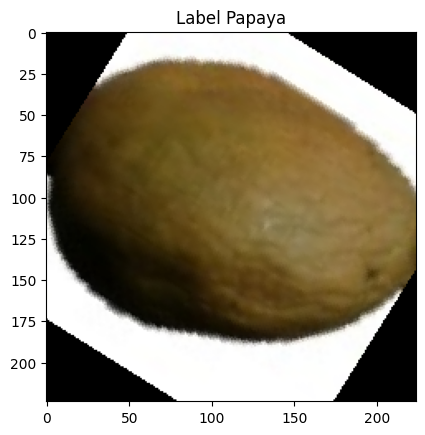

(224, 224, 3)


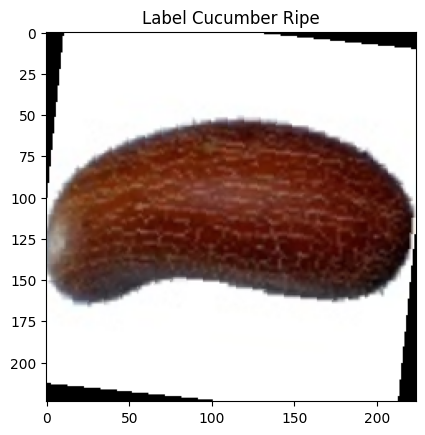

(224, 224, 3)


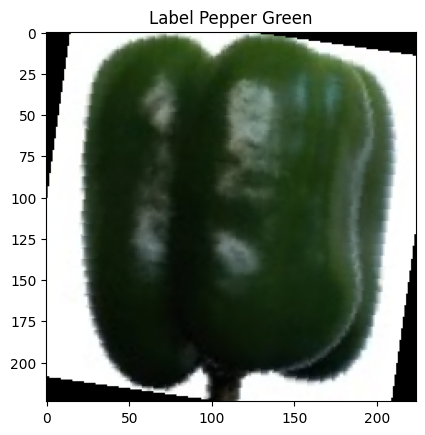

In [14]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = all_dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

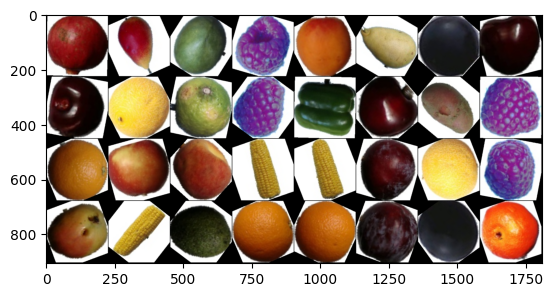

In [15]:
from torchvision.utils import make_grid
loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)
batch, labels = next(iter(loader))
grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор
plt.imshow(grid)

In [16]:
batch.shape

torch.Size([32, 3, 224, 224])

In [17]:
img, label = train_data[0]
img.shape

torch.Size([3, 224, 224])

In [18]:
3*224*224

150528

In [19]:
from torch import nn

#нейромережа
model = nn.Sequential(
    nn.Flatten(),   # переведе зображення 3х224х224 в нейрони 150528
    nn.Linear(150528, 128),   # на вході 150528 нейронів передає інформацію 128 нейронам
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes)  # 33 (!) нейрони на кожен фрукт
    
)


# підключення до процесора
model = model.to(device)
img = img.to(device)
# print(img.shape)
img = img.unsqueeze(0)
model(img)

tensor([[ 0.0623,  0.0446,  0.1108, -0.0984,  0.0651, -0.1460, -0.0638, -0.0915,
         -0.1107,  0.2587, -0.0349,  0.0078, -0.0180,  0.0754,  0.1178,  0.0907,
         -0.0329, -0.0548, -0.1469, -0.0487,  0.0326, -0.1685, -0.1581,  0.0576,
          0.0604, -0.0341,  0.1459,  0.0894, -0.0167, -0.0999,  0.0173, -0.1549,
         -0.0783]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [20]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нейромережі
    lr=0.001
)

loss_list = []
loss_test_list = []
for i in range(10):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # test data
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"loss: {loss}")

        loss_test_list.append(loss.cpu().item())

loss: 3.5013203620910645
loss: 17.595922470092773
loss: 24.933717727661133
loss: 26.529582977294922
loss: 20.984996795654297
loss: 15.24801254272461
loss: 13.753446578979492
loss: 12.443687438964844
loss: 12.20889663696289
loss: 9.261112213134766
loss: 7.9344587326049805
loss: 7.075190544128418
loss: 6.102419853210449
loss: 6.189043998718262
loss: 5.862605571746826
loss: 4.830299377441406
loss: 4.947352409362793
loss: 4.283316612243652
loss: 3.970104217529297
loss: 3.8751893043518066
loss: 3.516657829284668
loss: 3.383601665496826
loss: 3.3452820777893066
loss: 3.3654067516326904
loss: 3.3600754737854004
loss: 3.228470802307129
loss: 3.1840243339538574
loss: 3.0702219009399414
loss: 3.149501323699951
loss: 3.170522451400757
loss: 2.9354376792907715
loss: 2.9414191246032715
loss: 2.9040937423706055
loss: 3.065676689147949
loss: 2.97001314163208
loss: 2.971670150756836
loss: 2.9286272525787354
loss: 2.899716377258301
loss: 2.8561601638793945
loss: 2.8722496032714844
loss: 2.7698075771331

In [21]:
img, label = train_data[0]
img = img.unsqueeze(0)
img.shape
img = img.to(device)
prediction = model(img)

print(label)
print(torch.softmax(prediction, dim=1))

19
tensor([[1.6696e-11, 5.7742e-06, 1.3381e-09, 9.0630e-07, 6.5009e-07, 2.9601e-16,
         5.0941e-05, 3.9341e-13, 7.1745e-14, 1.4590e-08, 8.3781e-10, 3.1822e-07,
         1.7357e-13, 1.6578e-02, 8.3444e-07, 1.2471e-10, 1.7200e-12, 3.6037e-06,
         1.8661e-12, 9.8334e-01, 6.0413e-13, 8.7532e-10, 1.9659e-06, 1.1791e-11,
         7.6422e-09, 3.3176e-07, 2.3651e-12, 3.1010e-07, 9.7502e-09, 1.6159e-11,
         1.7015e-05, 2.6849e-06, 3.1952e-08]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


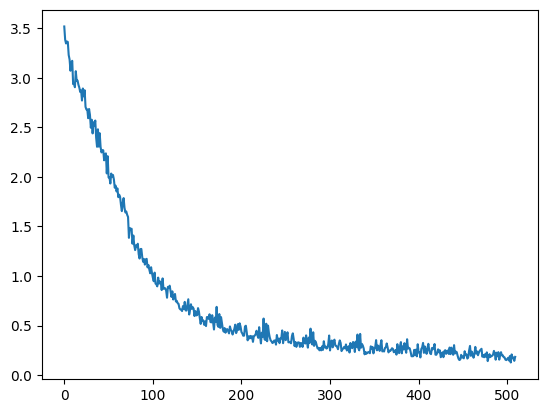

In [22]:
import matplotlib.pyplot as plt

new_list = loss_list[20:]
plt.plot(new_list)